# BacPT gene-interaction (Jacobian) matrix

This notebook computes BacPT's perturbation-based gene-interaction matrix (manuscript Methods: *"Calculation of Jacobian matrices"*), using the released `BacPT-large` weights and the bundled E. coli K-12 reference genome — no external database or extra download is needed beyond the public model weights.

For each gene $i$, its input embedding is replaced with a zero vector while every other gene keeps its original embedding and the **full genome stays as model context**. The influence of gene $i$ on gene $j$ is

$$\Delta_{i,j} = \lVert y_j - y_j^{(i)} \rVert_2$$

where $y_j$ is the unperturbed prediction for gene $j$ and $y_j^{(i)}$ is the prediction when gene $i$ is masked. The raw matrix is then mean-centered, made symmetric, and corrected for background signal (average product correction) — see `inference/jacobian.py` for the exact steps.

**Notes on this demo:**
- The gene window below is an **arbitrary** slice of the genome, chosen only to keep the example fast — it is not a biologically validated cluster (no MiBIG/STRING benchmarking here).
- A **GPU is recommended**. A full 5,000-position forward pass of BacPT can need well over 8GB of memory; this was confirmed while building this notebook. `inference/jacobian.py`'s `--device` flag can be pointed at a GPU to scale this up toward full-genome size.
- The gene set used as *rows* and *columns* is the same for both — the symmetrization step needs a square matrix over one consistent gene index set.

In [1]:
import sys
from pathlib import Path

REPO_ROOT = Path.cwd().resolve().parents[1]
sys.path.insert(0, str(REPO_ROOT))

import numpy as np
import pandas as pd
import torch
from matplotlib import pyplot as plt

from inference.load_bacpt import load_bacpt_release
from inference.prepare_input import prepare_input
from inference.jacobian import compute_raw_jacobian, postprocess_jacobian

## Load the bundled E. coli K-12 reference

This reuses the exact pattern documented in `data/ecoli_k12/README.md`: an ordered protein FASTA, its precomputed ESM2 embeddings, and the fitted input scaler.

In [2]:
ECOLI_DIR = REPO_ROOT / "data" / "ecoli_k12"

protein_ids, normalized, omitted = prepare_input(
    ECOLI_DIR / "ordered_proteins.faa",
    ECOLI_DIR / "esm2_onlyaa.npz",
    ECOLI_DIR / "scaler.npz",
)
print(f"{len(protein_ids)} genes loaded; {len(omitted)} omitted for length")

4297 genes loaded; 1 omitted for length


## Load BacPT-large

Downloads (and caches) the public `palsetuf/BacPT-large` release weights from the Hugging Face Hub — no local checkpoint file needed.

In [3]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)
if device.type == "cpu":
    print("Warning: no GPU detected. Keep NUM_GENES small below; a full-genome run needs a GPU.")

model, _ = load_bacpt_release("large", device=device)

Using device: cuda


## Compute the Jacobian over a demo window

`START_GENE`/`NUM_GENES` select an arbitrary window of genes to perturb and measure; the model still sees the **entire** genome as context on every forward pass.

In [4]:
START_GENE = 0
NUM_GENES = 50

positions = np.arange(START_GENE, START_GENE + NUM_GENES)
raw = compute_raw_jacobian(model, normalized, positions=positions, batch_size=2, device=device)
processed = postprocess_jacobian(raw)
print("Jacobian matrix shape:", processed.shape)

Jacobian matrix shape: (50, 50)


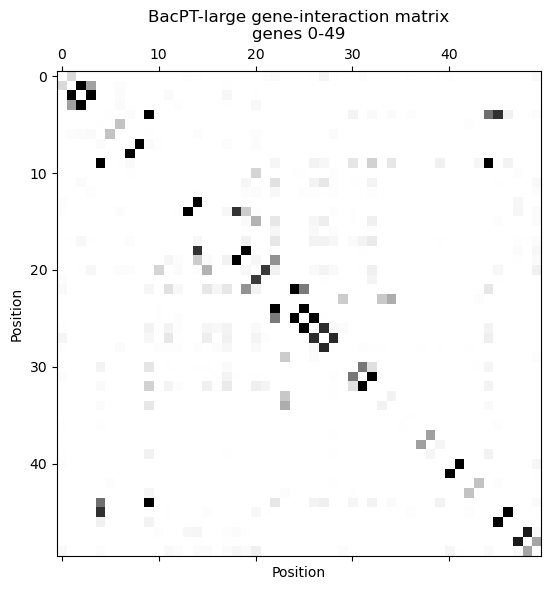

In [ ]:
vmax = np.percentile(processed, 99)

fig, ax = plt.subplots(figsize=(6, 6))
ax.matshow(processed, cmap="Greys", vmin=0, vmax=vmax)
ax.set_title(f"BacPT-large gene-interaction matrix\ngenes {START_GENE}-{START_GENE + NUM_GENES - 1}")
ax.set_xlabel("Position")
ax.set_ylabel("Position")
plt.tight_layout()
plt.show()

## Top interacting gene pairs in this window

Mapped back to real E. coli K-12 protein IDs via `data/ecoli_k12/protein_ids.tsv`.

In [6]:
id_table = pd.read_csv(ECOLI_DIR / "protein_ids.tsv", sep="\t").set_index("model_index")

triu_i, triu_j = np.triu_indices_from(processed, k=1)
scores = processed[triu_i, triu_j]
order = np.argsort(scores)[::-1][:10]

rows = []
for k in order:
    gi, gj = positions[triu_i[k]], positions[triu_j[k]]
    rows.append({
        "gene_i": id_table.loc[gi, "protein_id"],
        "gene_j": id_table.loc[gj, "protein_id"],
        "distance": abs(int(gi) - int(gj)),
        "score": scores[k],
    })
pd.DataFrame(rows)

,gene_i,gene_j,distance,score
0,NP_414555.1,NP_414556.1,1,34.752143
1,NP_414544.1,NP_414545.1,1,26.949119
2,NP_414564.1,NP_414566.1,2,22.418036
3,NP_414583.2,NP_414584.1,1,19.154459
4,NP_414546.1,NP_414551.1,5,18.658869
5,NP_414560.1,NP_414561.1,1,17.898792
6,NP_414566.1,NP_414567.1,1,13.848848
7,NP_414573.1,NP_414574.1,1,12.940471
8,NP_414543.1,NP_414544.1,1,12.929449
9,NP_414551.1,NP_414587.1,35,12.891822
